In [ ]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")
print(f"Current Working Directory: {os.getcwd()}")

# Function to display images in Jupyter
def show_images(original, restored, title_orig="Original", title_rest="Restored"):
    plt.figure(figsize=(15, 10))

    # Convert BGR to RGB for matplotlib
    if original is not None:
        if original.ndim == 3:
            original_show = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        else:
            original_show = original

        plt.subplot(1, 2, 1)
        plt.imshow(original_show)
        plt.title(title_orig)
        plt.axis('off')

    if restored is not None:
        if restored.ndim == 3:
            restored_show = cv2.cvtColor(restored, cv2.COLOR_BGR2RGB)
        else:
            restored_show = restored

        plt.subplot(1, 2, 2)
        plt.imshow(restored_show)
        plt.title(title_rest)
        plt.axis('off')

    plt.show()

Libraries imported successfully.
Current Working Directory: /content


In [ ]:
# 1. Load Image
img_path = 'Picture1.jpg'

# Check if file exists
if not os.path.exists(img_path):
    print(f"Error: '{img_path}' not found in current directory.")
    print("Files in current directory:", os.listdir())
    img = None
else:
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Failed to load '{img_path}'. The file might be corrupted or not an image.")
    else:
        print(f"Image loaded successfully. Shape: {img.shape}")

Image loaded successfully. Shape: (660, 1540, 3)


In [ ]:
# 2. Denoising
if img is not None:
    print("Denoising may take a few seconds...")
    # increased h and hColor for better denoising on old painting
    denoised_img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
    print("Denoising complete.")
else:
    denoised_img = None
    print("Skipping Denoising due to load error.")

Denoising may take a few seconds...
Denoising complete.


In [ ]:
# 3. Brightness and Contrast Enhancement
if denoised_img is not None:
    print("Enhancing contrast...")
    lab = cv2.cvtColor(denoised_img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    # Merge channels back
    limg = cv2.merge((cl, a, b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    print("Contrast enhancement complete.")
else:
    enhanced_img = None
    print("Skipping Enhancement.")

Enhancing contrast...
Contrast enhancement complete.


In [ ]:
# 4. Sharpening
if enhanced_img is not None:
    print("Sharpening...")
    gaussian_blur = cv2.GaussianBlur(enhanced_img, (0, 0), 3.0)
    unsharp_image = cv2.addWeighted(enhanced_img, 1.5, gaussian_blur, -0.5, 0)
    print("Sharpening complete.")
else:
    unsharp_image = None
    print("Skipping Sharpening.")

Sharpening...
Sharpening complete.


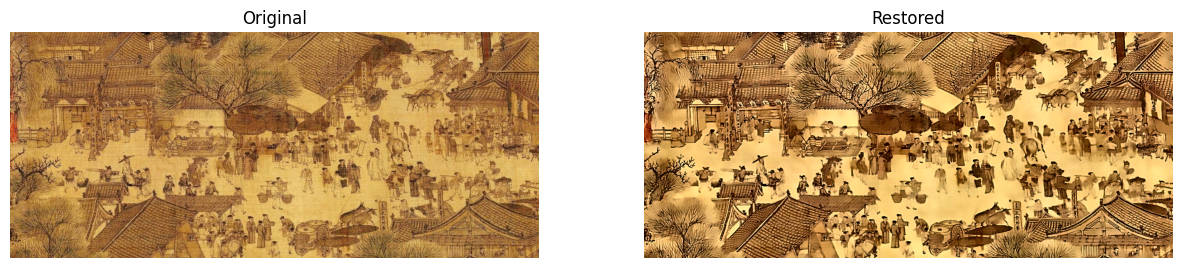

Saved restored image as 'Restored_Picture1.jpg'


In [ ]:
# Display Results
if unsharp_image is not None:
    show_images(img, unsharp_image, "Original", "Restored")

    # Save the result
    cv2.imwrite('Restored_Picture1.jpg', unsharp_image)
    print("Saved restored image as 'Restored_Picture1.jpg'")
else:
    print("Nothing to display or save due to previous errors.")